# ITAMAE: usage walkthrough

## Goal
Try the shared building blocks, compose a toy population pipeline, and export a weighted catalogue. The toy laws below deliberately have analytic answers; they are not CDM/SIDM/WDM/FDM models.

Run **Restart Kernel and Run All**. Every code cell is required, including the checks. These small grids teach the API; they are not converged predictions or a replacement for scientific regression tests.

## Setup
Use Python 3.12 in a clean virtual environment, from this repository's `itamae-migration` checkout:
```sh
python -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install . numpy scipy matplotlib astropy colossus h5py numexpr tqdm nbformat nbclient ipykernel
python -m ipykernel install --user --name sashimi-walkthrough
```
Select that kernel. ITAMAE means this project's GitHub package; do not substitute an unrelated package with the same PyPI name. No data download is performed by notebook cells. F uses its packaged Planck power table and a temporary cache.


In [1]:
import sys, tempfile
from pathlib import Path
from importlib.metadata import version
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from itamae.provenance import source_revision
packages = ['itamae']
display({p: {"version": version(p), "source_revision": source_revision(p)} for p in packages})
print(sys.version)
rng = np.random.default_rng(20260907)
workspace = tempfile.TemporaryDirectory(prefix="itamae-walkthrough-")
work = Path(workspace.name)

3.12.13 (main, Aug  7 2026, 02:25:39) [Clang 22.1.3 ]


{'itamae': {'version': '0.1.0a4',
  'source_revision': '1c5b1ad67725671fd4dc1a2306d2731ba337e563'}}

## Units and cosmology
Canonical lengths are Mpc and masses are solar masses. Astropy performs explicit conversions; native arrays must already obey the canonical contract.

In [2]:
from itamae.units import NativeUnits
from itamae.units.astropy import AstropyUnits
from itamae.cosmology import NativeFlatLCDM
from itamae.cosmology.colossus import ColossusCosmology
import astropy.units as u
np.testing.assert_allclose(AstropyUnits().to_internal(2000*u.kpc, "length"), 2)
NativeUnits().validate([1e10, 1e12], "mass")
cosmo = NativeFlatLCDM()
z = np.array([0., 1., 3.])
display({"z": z, "H": cosmo.H(z), "growth": cosmo.growth_factor(z), "time": cosmo.cosmic_time(z)})
np.testing.assert_allclose(cosmo.growth_factor(0), 1)
print("optional Colossus H:", ColossusCosmology("planck18").H(z))

optional Colossus H: [ 67.66       120.63743463 307.25838249]


{'z': array([0., 1., 3.]),
 'H': array([ 67.4       , 120.66294294, 307.72362958]),
 'growth': array([1.        , 0.60761975, 0.31574595]),
 'time': array([13.79623464,  5.84562194,  2.14200666])}

## Halo profile and inversion
NFW enclosed mass and the inverse dimensionless mass function are useful independently of any population model.

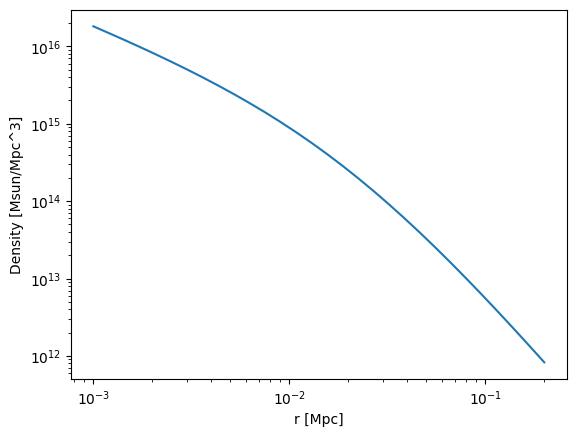

In [3]:
from itamae.halo import NFWProfile, nfw_mass_function, invert_nfw_mass_function
profile = NFWProfile(r_s=0.02, rho_s=1e15)
radius = np.geomspace(.001, .2, 30)
assert np.all(np.diff(profile.enclosed_mass(radius)) > 0)
x = np.array([.1, 1., 10.])
np.testing.assert_allclose(invert_nfw_mass_function(nfw_mass_function(x)), x, rtol=1e-8)
plt.loglog(radius, profile.density(radius))
plt.xlabel("r [Mpc]"); plt.ylabel("Density [Msun/Mpc^3]"); plt.show()

## Power spectrum, window and variance
This dimensionless constant-power toy has an analytic sharp-k variance. Changing the window or growth law changes the model; a shared interface does not imply equivalent physics.

In [4]:
from itamae.power import TabulatedPowerSpectrum, SharpKWindow
from itamae.variance import IntegratedVarianceModel, variance_cache_key, save_variance_cache, load_variance_cache
k = np.logspace(-3, 3, 6001)
power = TabulatedPowerSpectrum(k, np.ones_like(k), identifier="walkthrough:constant-power")
variance = IntegratedVarianceModel(power=power, window=SharpKWindow(), rho_mean=3/(4*np.pi),
    k_min=1e-3, k_max=1e3, n_k=6001, filter_scale=1.,
    growth_function=lambda z: 1/(1+np.asarray(z)), growth_identifier="toy-growth")
np.testing.assert_allclose(variance.variance(1., 0.), (1-1e-9)/(6*np.pi**2), rtol=1e-9)
np.testing.assert_allclose(variance.dvariance_dmass(1., 0.), -1/(6*np.pi**2), rtol=1e-9)
masses = np.geomspace(1, 100, 20)
values = variance.variance(masses)
key = variance_cache_key(variance.identifier, masses, backend_identifier="numpy", settings={"example":"toy"})
save_variance_cache(work/"variance.npz", key=key, mass=masses, variance=values)
loaded_mass, loaded_variance = load_variance_cache(work/"variance.npz", expected_key=key)
np.testing.assert_array_equal(loaded_variance, values)
print(variance.identifier)

integrated-variance:v2;power=(tabulated-power:interpolation=log-log;source=(walkthrough:constant-power));window=(window:sharp-k:v1);rho_mean=0.238732414637843;k=[0.001,1000];n_k=6001;filter_scale=1;toy-growth


## Evolution solver
Check an exponential decay before using a solver inside a physical evolution model.

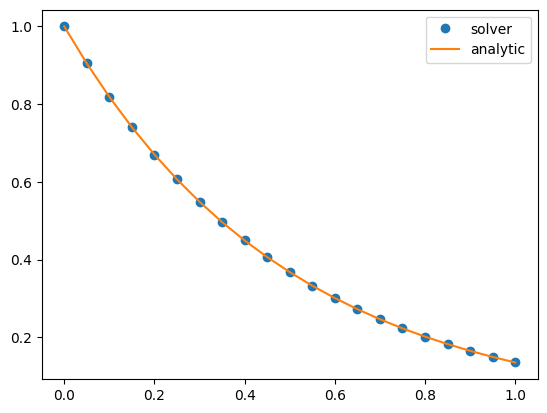

In [5]:
from itamae.evolution import solve_evolution, shanks_transform
times = np.linspace(0, 1, 21)
solution = solve_evolution(lambda t, state, rate: -rate*state, [1.], times, args=(2.,))[:, 0]
np.testing.assert_allclose(solution, np.exp(-2*times), rtol=1e-5)
np.testing.assert_allclose(shanks_transform(1., 1.5, 1.75), 2.)
plt.plot(times, solution, "o", label="solver"); plt.plot(times, np.exp(-2*times), label="analytic")
plt.legend(); plt.show()

## Compose an accretion/evolution/survival pipeline
The model supplies callbacks; ITAMAE transports aligned arrays and factorized weights. These four toy nodes demonstrate the public execution interface, not a calibrated accretion model.

In [6]:
from itamae.measure import build_accretion_batch
from itamae.execution import PopulationPipeline
from itamae.types import CatalogMetadata
batch = build_accretion_batch(np.array([1., 2., 3., 4.]), .5, np.full(4, 5.),
    np.array([.2, .3, .4, .5]), np.ones(4), mvir_acc=np.array([1.1, 2.2, 3.3, 4.4]))
pipeline = PopulationPipeline(
    initialize=lambda batch, context: {"initial": batch.mvir_acc},
    evolve=lambda batch, initial, context: {"m_bound": initial["initial"]*context},
    survival=lambda batch, initial, evolved, context: {"surviving": evolved["m_bound"] > 1},
    columns=lambda batch, initial, evolved, survival, context: {"m200_acc": batch.m200_acc, "m_bound": evolved["m_bound"]})
execution = pipeline.execute([batch], contexts=[.8])
catalog = execution.to_catalog(CatalogMetadata(model_identifier="walkthrough:toy", backend_identifier="numpy"), view="surviving")
np.testing.assert_allclose(catalog.columns["m_bound"], batch.mvir_acc*.8)

## Inspect the catalogue contract
Rows are quadrature nodes, not individual satellites. `weight_final` combines the stored population and survival factors. Inspect the metadata before comparing physics modes or converting units; column names alone do not establish a unit convention.

In [7]:
from itamae.types import WeightedSubhaloCatalog
print("nodes:", catalog.shape, "expected surviving count:", float(catalog.weight_final.sum()))
print("columns:", sorted(catalog.columns))
print("weight factors:", sorted(catalog.weights))
display(catalog.metadata)
assert np.all(np.isfinite(catalog.weight_final))
assert np.all(catalog.weight_final >= 0)
assert catalog.weight_final.sum() > 0

nodes: (4,) expected surviving count: 1.2
columns: ['m200_acc', 'm_bound']
weight factors: ['weight_base', 'weight_concentration', 'weight_survival']


mappingproxy({'schema_version': '1.0',
              'model_identifier': 'walkthrough:toy',
              'backend_identifier': 'numpy'})

## Select a population and plot its weighted mass function
A histogram sums expected counts, then division by the logarithmic bin width gives dN/dln M. Changing the mass range changes the population included; this is not a convergence test.

weighted bound mass: 3.3440000000000003


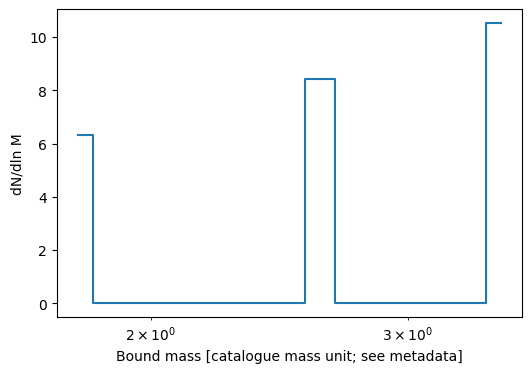

In [8]:
mass = np.asarray(catalog.columns["m_bound"])
positive = (mass > 0) & (catalog.weight_final > 0)
selected = catalog.select(positive)
edges = np.geomspace(mass[positive].min()*0.99, mass[positive].max()*1.01, 16)
counts, edges = selected.weighted_histogram("m_bound", bins=edges)
np.testing.assert_allclose(counts.sum(), selected.weight_final.sum())
fig, ax = plt.subplots(figsize=(6, 4))
ax.step(np.sqrt(edges[:-1]*edges[1:]), counts/np.diff(np.log(edges)), where="mid")
ax.set(xscale="log", xlabel="Bound mass [catalogue mass unit; see metadata]", ylabel="dN/dln M")
plt.show()
print("weighted bound mass:", selected.weighted_sum(selected.columns["m_bound"]))

## Save and reload without pickle
NPZ retains the catalogue's columns, factorized weights and metadata. The round-trip checks make this notebook useful as a migration smoke test.

In [9]:
path = work / "catalog.npz"
catalog.to_npz(path)
restored = WeightedSubhaloCatalog.from_npz(path)
for name in catalog.columns:
    np.testing.assert_array_equal(restored.columns[name], catalog.columns[name])
np.testing.assert_array_equal(restored.weight_final, catalog.weight_final)
assert restored.metadata == catalog.metadata
print("NPZ round trip passed")

NPZ round trip passed


## Reproducible realization and concatenation
Poisson sampling requires an explicit generator. Our toy weights keep the draw bounded in expectation; do not sample a huge production catalogue without first inspecting its expected count.

In [10]:
draw = catalog.poisson_realization(np.random.default_rng(42))
repeat = catalog.poisson_realization(np.random.default_rng(42))
np.testing.assert_array_equal(draw["m_bound"], repeat["m_bound"])
combined = WeightedSubhaloCatalog.concatenate([catalog, catalog])
np.testing.assert_allclose(combined.weight_final.sum(), 2*catalog.weight_final.sum())
print("realized nodes:", len(draw["m_bound"]))

realized nodes: 2


## Spatial and orbital primitives
An isolated Kepler orbit in units GM=1 has a known period. These primitives are available; their full integration with subhalo evolution is still migration work.

In [11]:
from itamae.spatial import turning_points, radial_period, orbit_radial_measure
potential = lambda r: -1/np.asarray(r)
energy, angular_momentum = -.5, np.sqrt(.75)
rp, ra = turning_points(potential, energy, angular_momentum, .1, 3.)
np.testing.assert_allclose([rp, ra], [.5, 1.5], rtol=1e-9)
period = radial_period(potential, energy, angular_momentum, rp, ra)
np.testing.assert_allclose(period, 2*np.pi, rtol=1e-8)
measure = orbit_radial_measure(np.linspace(rp, ra, 17), potential, energy, angular_momentum, rp, ra)
np.testing.assert_allclose(measure.weight.sum(), 1.)
print("turning points, period:", rp, ra, period)

turning points, period: 0.4999999999999999 1.4999999999998446 6.2831853067699575


## Coverage and next steps

| Area | Runnable example |
|---|---|
| Units/backends/cosmology | Native + Astropy + Colossus |
| Halo | NFW and inversion |
| Power/variance/cache | Analytic sharp-k check and cache round trip |
| Evolution | ODE and acceleration check |
| Accretion/execution/types | Callback pipeline |
| Catalogue | Selection, histogram, export, realization, concatenate |
| Spatial | Kepler orbit |

See `tests/` for lower-level protocol, quadrature and validation cases. Full orbital population integration and metadata hardening remain tracked in sashimi-family issues; this notebook does not claim they are complete.

When a public feature is added or migrated, update this table, its runnable example and its checks in the same PR. Existing migration demos remain the detailed numerical comparison reference; passing this walkthrough does not close their separate regeneration work.

In [12]:
workspace.cleanup()
print("All walkthrough checks passed")

All walkthrough checks passed
